# Raport z laboratorium 2

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom

## Zadanie 1

Nalezy dodac obliczenia mle do raportu. powinno wyjsc p = mean(x) / 5 mi wyszlo z -5 sprawdz pochodne

In [ ]:
def mle(X):
    return np.mean(X) / 5

In [ ]:
ns = [20, 50, 100]
ps = np.arange(0.1, 1, 0.2)
num_runs = 10000

results = {}
for n in ns:
    for p in ps:
        ppb_values = []
        for _ in range(num_runs):
            X = binom.rvs(5, p, size=n)
            p_mle = mle(X)

            ppb = binom.pmf(3, 5, p_mle) + binom.pmf(4, 5, p_mle) + binom.pmf(5, 5, p_mle)

            ppb_values.append(ppb)
        results[n, p] = ppb_values

In [ ]:
for n in ns:
    plt.plot(results[n])

      n    p  mean_ppb
0    20  0.1  0.010627
1    20  0.3  0.168046
2    20  0.5  0.500336
3    20  0.7  0.831246
4    20  0.9  0.989486
5    50  0.1  0.009305
6    50  0.3  0.165497
7    50  0.5  0.500354
8    50  0.7  0.834993
9    50  0.9  0.990622
10  100  0.1  0.008948
11  100  0.3  0.163903
12  100  0.5  0.499825
13  100  0.7  0.835693
14  100  0.9  0.991091


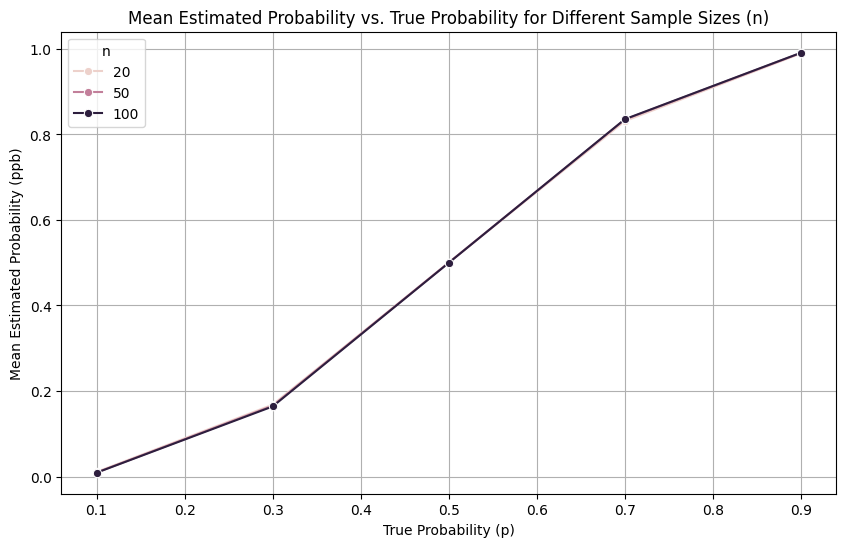

In [ ]:
# Calculate the mean ppb for each (n, p) combination
mean_ppbs = {}
for (n, p), data in results.items():
    mean_ppbs[(n, p)] = np.mean(data)

# Prepare data for plotting
plot_data = []
for (n, p), mean_ppb in mean_ppbs.items():
    plot_data.append({'n': n, 'p': p, 'mean_ppb': mean_ppb})

plot_df = pd.DataFrame(plot_data)
print(plot_df)
# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='p', y='mean_ppb', hue='n', marker='o')
plt.xlabel('True Probability (p)')
plt.ylabel('Mean Estimated Probability (ppb)')
plt.title('Mean Estimated Probability vs. True Probability for Different Sample Sizes (n)')
plt.grid(True)
plt.show()